<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week5/diabetes_DL_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week2/diabetes.csv'

df = pd.read_csv(path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df = df.drop('Outcome', axis=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64
Axes(0.125,0.11;0.775x0.77)


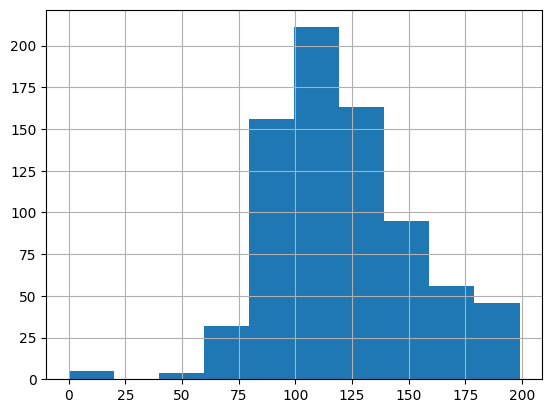

In [ ]:
y = df['Glucose']
print(y.describe())
print(y.hist())

In [ ]:
X = df.drop('Glucose', axis=1)
X.head()

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,72,35,0,33.6,0.627,50
1,1,66,29,0,26.6,0.351,31
2,8,64,0,0,23.3,0.672,32
3,1,66,23,94,28.1,0.167,21
4,0,40,35,168,43.1,2.288,33


## 1. 데이터 형태 변환 + 데이터 분할 + Scaling




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.values
y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(614, 7) (154, 7)
(614,) (154,)


## 2. 딥러닝 모델 생성, 학습, 평가

In [ ]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 현재 7개의 열을 입력
    layers.Dense(64, activation='relu'), # 은닉층
    layers.Dropout(0.3), # Drop out
    layers.Dense(32, activation='relu'), #은닉층
    layers.Dense(1) #출력 1 Regression이므로 activation이 존재하지 않음
])

model.compile(
    optimizer='adam',
    loss='mse', # Regression이므로 loss function이 mse
    metrics=['mae', 'mse'] # Regression이므로 metrics가 mae(평균 절대 오차), mse이다.
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 15724.6377 - mae: 121.2249 - mse: 15724.6377 - val_loss: 14398.9326 - val_mae: 116.1804 - val_mse: 14398.9316
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15289.5977 - mae: 119.4370 - mse: 15289.5977 - val_loss: 13817.5635 - val_mae: 113.6788 - val_mse: 13817.5635
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14407.3271 - mae: 115.7046 - mse: 14407.3271 - val_loss: 12628.9854 - val_mae: 108.3829 - val_mse: 12628.9854
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12783.0303 - mae: 108.6195 - mse: 12783.0303 - val_loss: 10663.4385 - val_mae: 98.9305 - val_mse: 10663.4385
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10337.3428 - mae: 96.3530 - mse: 10337.3428 - val_loss: 7899.9575 - val_mae: 83.7459 - val_mse: 7899.9575
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7419.4268 - mae: 79.9689 - mse: 7419.4268 - val_loss: 4889.5718 - val_mae: 63.0390 - val_mse: 4889.5718
E

## 3. 예측 및 평가

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

y_pred = y_pred.flatten()
y_test = y_test.flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse) # Root MSE
print("MAE :", mae)
print("R2  :", r2) # 결정계수(coefficient of determination)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
MSE : 904.13818359375
RMSE: 30.068890627918915
MAE : 21.995250701904297
R2  : 0.14993023872375488


## 4. 학습 과정 시각화

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(loss) + 1)

## 손실 그래프

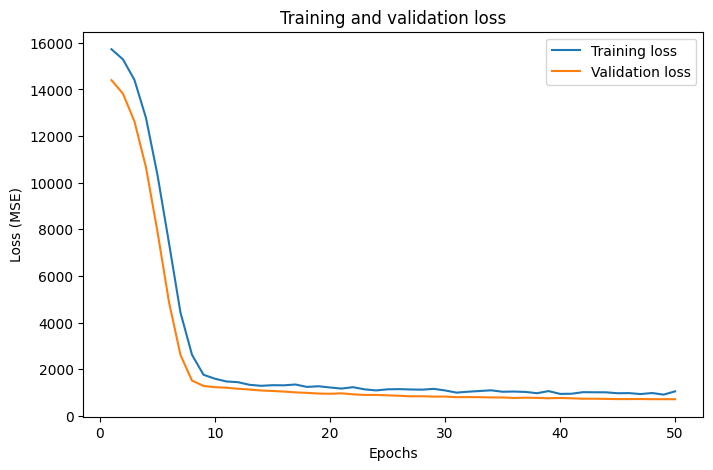

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## MAE 그래프

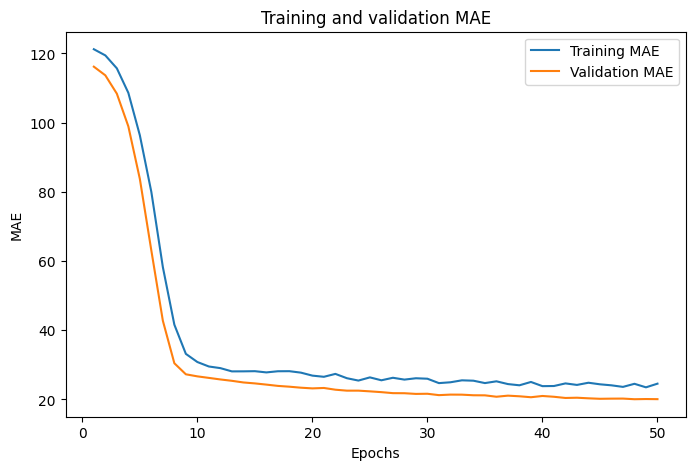

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()